# Exploratory data analysis 1

**INPUT**: Raw corpus

**OUTPUT**: Preprocessing decisions + Stratified split

| Step | Decision | Status | Comment |
|------|----------|--------|---------|
| Columns & Shape | Drop some | Decided | Message ID and Date not valuable for this project, drop in preprocessing |
| Inspect metadata | Remove | Decided | Manual inspection, remove in preprocessing |
| Columns Subject & Message | Merge | Decided | Own decision, merge in preprocessing |
| Empty values | Remove | Decided | Insignificant amount, remove in preprocessing |
| Duplicates | Remove | Decided | Insignificant amount, remove in preprocessing |
| Label balance | No action | Done | Near 50-50 |
| Patterns | Replace | Decided | Replace them in preprocessing if they can be renormalized (they are exploded with spaces) |
| Message length distribution | Remove outliers | Decided | Use the 1.5xIQR (John Tukey) rule, lower is minus, add one manually |
| Repeated chars | Collapse them | Pending | Same char appearing > 3 times. Collapse them to unified 2 chars |
| Special chars | Keep some | Pending | Maybe ! ? % $ are meaningful keep them? Ask Consultant |
| Stratified split | In setup part | Done | The next steps are done on the train corpus |
| Vocabulary size estimation | Between 16-32k | Pending | For LSTM start with low, LLM can work with greater, read for heuristics |
| OOV rate estimation | Find patterns to replace | Pending | Chosen patterns: url, email, phone, uppercase. Have to fine tune regex patterns & normalize email and urls. |


## Input & Setup

### imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from config import PATHS, REGEXES
from urllib.request import urlretrieve
import zipfile
from sklearn.model_selection import train_test_split

### Build data directory tree

In [ ]:
PATHS.make_dirs()

### Download raw corpus and unzip it

In [ ]:
url = "https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.zip"
zip_path = PATHS.corpora_raw / "enron_spam_data.zip"

urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(PATHS.corpora_raw)

### Read data and make a copy of it

In [2]:
corpus = pd.read_csv(PATHS.corpus_raw)

### Stratified split, and save

In [9]:
train, temporary = train_test_split(
    corpus,
    test_size=0.3,
    random_state=42,
    stratify=corpus['Spam/Ham']
)
validation, test = train_test_split(
    temporary,
    test_size=0.5,
    random_state=42,
    stratify=temporary['Spam/Ham']
)
train.to_csv(PATHS.train_raw)
validation.to_csv(PATHS.validation_raw)
test.to_csv(PATHS.test_raw)

## Steps

### Columns and shape

In [ ]:
shape = corpus.shape
print(f"Number of entires: {shape[0]},\nNumber of columns: {shape[1]}")
print(f'Column names: {", ".join(corpus.columns)}')

Number of entires: 33716,
Number of columns: 5
Column names: Message ID, Subject, Message, Spam/Ham, Date


### Detect empty values

In [ ]:
empty_values = corpus.isnull().sum()
print("Number of empty values:")
for col, count in empty_values.sort_values(ascending=False).items():
    print(f"{col:<15} {count:>5}")

Number of empty values:
Message           371
Subject           289
Message ID          0
Spam/Ham            0
Date                0


### Detect duplicates

In [ ]:
count_duplicates = corpus.drop(['Message ID'], axis=1).duplicated().sum()
print(f"Duplicates found: {count_duplicates}")

Duplicates found: 2953


### Label balance inspection

In [ ]:
num_of_labels = corpus['Spam/Ham'].value_counts().to_dict()
percentage_of_labels = {key:round(value/len(corpus)*100, 2) for key,value in num_of_labels.items()}

print(f"Number of labels by class:\nSpam: {num_of_labels['spam']}\nHam: {num_of_labels['ham']}")
print(f"Percentage of labels by class:\nSpam: {percentage_of_labels['spam']} %\nHam: {percentage_of_labels['ham']} %")

Number of labels by class:
Spam: 17171
Ham: 16545
Percentage of labels by class:
Spam: 50.93 %
Ham: 49.07 %


### Patterns to replace

In [ ]:
# TODO: revise regex after normalized URLs and EMAILs (they contain spaces)
# TODO: revise regex for phone, is it useable? Or leave only num?
from dataclasses import fields

def number_of_patterns(column, regexes):
    for field in fields(regexes):
        k = field.name
        v = getattr(regexes, k)
        num = column.str.count(v).sum()
        print(f"{'Number of ' + k + 's:':<25} {num:>8g}")

number_of_patterns(corpus["Message"], REGEXES)

Number of regex_urls:                    0.0
Number of regex_emails:                  0.0
Number of regex_phones:               1951.0
Number of regex_nums:               498867.0
Number of regex_uppercases:              0.0
Number of regex_repeated_chars:      43947.0


### Message length distribution

In [6]:
msg_lengths = corpus["Message"].str.len()
char_length_statistics = msg_lengths.describe()

spam_msg_lengths = corpus[corpus['Spam/Ham'] == 'spam']['Message'].str.len()
spam_char_lengths_statistics = spam_msg_lengths.describe()

ham_msg_lengths = corpus[corpus['Spam/Ham'] == 'ham']['Message'].str.len()    
ham_char_lengths_statistics = ham_msg_lengths.describe()


def print_length_statistics(column):
    statistics = column.str.len().describe()
    for stat, value in statistics.items():
        print(f"{stat+':':<10} {value:>8.2f}")

print_length_statistics(corpus["Message"])

count:     33345.00
mean:       1486.68
std:        4304.45
min:           1.00
25%:         318.00
50%:         688.00
75%:        1529.00
max:       228353.00


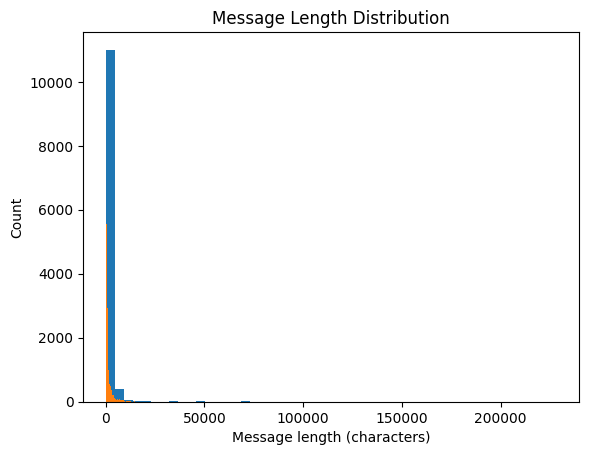

In [ ]:
plt.figure()
plt.hist(ham_msg_lengths, bins=50)
plt.hist(spam_msg_lengths, bins=50)
plt.xlabel("Message length (characters)")
plt.ylabel("Count")
plt.title("Message Length Distribution")
plt.show()

In [ ]:
q1 = char_length_statistics['25%']
q3 = char_length_statistics['75%']

def calculate_scaled_IQR(q1, q3, scaling_factor = 1.5):
    IQR = q3 -q1
    upper_boundary = int(q3 + scaling_factor*IQR)
    lower_boundary = int(q1 - scaling_factor*IQR)
    return upper_boundary, lower_boundary

upper, lower = calculate_scaled_IQR(q1,q3)
print("IQR rule outlier limits")
print(f"Upper limit: {upper}")
print(f"Lower limit: {lower}")
    

IQR rule outlier limits
Upper limit: 3345
Lower limit: -1498


### Vocabulary size estimation

In [18]:
estimated_tokens_train_set = train['Message'].astype(str).str.split()
vocab = set(token for msg in estimated_tokens_train_set for token in msg)
vocab_size = len(vocab)
print(f"Estimated vocabulary size: {vocab_size}")


Estimated vocabulary size: 131303


### Out of vocabulary rate (OOV) estimation

In [21]:
oov_tokens = 0

estimated_tokens_validation_set = validation['Message'].astype(str).str.split()

for message in estimated_tokens_validation_set:
    for token in message:
        if token not in vocab:
            oov_tokens += 1

oov_rate = (oov_tokens / vocab_size) * 100
print(f"Out of vocabulary rate: {oov_rate:3.1f}%")

Out of vocabulary rate: 11.9%
